In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2026-01-29 18:30:14.422716


In [2]:
from pathlib import Path
import sys
import os
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.colors as clr
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import seaborn as sns

In [3]:
# plt.rcdefaults()

In [7]:
# plt.rcParams['figure.figsize'] = (4,4)
plt.rcParams['figure.figsize'] = (3,3)
# plt.rcParams["figure.dpi"] = 300

In [8]:
# make text editable as words in output plots
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

In [22]:
sys.path.append(str(Path.cwd().resolve().parents[1]))

from config.paths import BASE_DIR

base_dir = BASE_DIR 

input_dir = BASE_DIR / "data/h5ad/export_04/04c_gamma_subtypes"
input_file = input_dir / 'neurons-final-labels.h5ad' # using 1000 transcripts/cell filtering, final neuron_label

print(input_file)

/home/workspace/DRG/spatial_mouse_drg_outputs/yano/data/h5ad/export_04/04c_gamma_subtypes/neurons-final-labels.h5ad


In [23]:
output_dir = os.path.join(base_dir, "spatial_mouse_drg_outputs/yano")

plot_out_dir = os.path.join(output_dir, "plots")
if not os.path.exists (plot_out_dir):
    os.makedirs(plot_out_dir)

In [15]:
adata = sc.read_h5ad(input_file)

## Plotting functions

In [16]:
import matplotlib.pyplot as plt

def plot_umaps(
    adata,
    label_cols,
    true_color_map,
    false_color,
    true_size,
    false_size,
    edgecolor,
    linewidth,
    alpha_false,
    alpha_true,
    figsize=(3, 3),
    save_path  = None
):
    """
    Plot minimalist UMAPs for boolean label columns.
    No title, no axes, no border.
    """

    if "X_umap" not in adata.obsm:
        raise ValueError("No UMAP found in adata.obsm['X_umap'].")

    x, y = adata.obsm["X_umap"][:, 0], adata.obsm["X_umap"][:, 1]

    for col in label_cols:
        if col not in adata.obs.columns:
            print(f"Column `{col}` not in adata.obs — skipping.")
            continue

        if col not in true_color_map:
            raise ValueError(f"Missing true_color_map entry for `{col}`.")

        true_color = true_color_map[col]
        mask = adata.obs[col].astype(bool).values

        plt.figure(figsize=figsize)

        # Plot FALSE background
        plt.scatter(
            x[~mask],
            y[~mask],
            s=false_size,
            c=false_color,
            linewidths=0,
            alpha=alpha_false,
        )

        # Plot TRUE foreground
        plt.scatter(
            x[mask],
            y[mask],
            s=true_size,
            c=true_color,
            linewidths=linewidth,
            edgecolors=edgecolor,
            alpha=alpha_true,
        )

        ax = plt.gca()
        ax.set_aspect("equal", "box")

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_title("")  # remove title
        ax.spines["top"].set_visible(False)
        ax.spines["bottom"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.spines["right"].set_visible(False)

        plt.tight_layout()

        if save_path is not None:
            plt.savefig(os.path.join(save_path, f"umap_{col}.pdf"), format='pdf', bbox_inches='tight')

        plt.show()

In [17]:
def barplot_dual_distribution(
    adata,
    population_name,
    group_col="neuron_label",
    dual_col="EGFP_dTomato_dual_hi",
    bar_color="black",
    figsize=(4, 4),
    fontsize=11,
    plot_counts = True,
    return_group_order=False,
    group_order=None,
):
    df = adata.obs[[group_col, dual_col]].copy()
    df[dual_col] = df[dual_col].astype(bool)
    df[group_col] = df[group_col].astype(str).replace("nan", "Unknown")

    # Count dual positives per group (correct)
    dual_counts = df.groupby(group_col)[dual_col].sum()

    total_dual = dual_counts.sum()
    print('number +: ', total_dual)

    # percentage
    stats = (dual_counts / total_dual * 100).sort_values(ascending=False)

    if group_order is not None:
        # Use the provided order. .reindex ensures we handle missing/extra groups safely.
        # Fill missing groups with 0 so the bars show up as empty instead of crashing.
        stats = stats.reindex(group_order).fillna(0)
    else:
        # Default: Sort by percentage descending
        stats = stats.sort_values(ascending=False)
    
    # Final order of categories
    final_order = stats.index.tolist()
    sorted_counts = dual_counts.reindex(final_order).fillna(0)

    # # ordered counts
    # sorted_counts = dual_counts.loc[stats.index]

    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(len(stats))
    if plot_counts:
        ax.bar(x, sorted_counts.values, color=bar_color, alpha=0.9)
    else:
        ax.bar(x, stats.values, color=bar_color, alpha=0.9)

    # xticks
    ax.set_xticks(x)
    ax.set_xticklabels(stats.index, rotation=45, ha="right", fontsize=fontsize)

    # y-axis
    if plot_counts:
        ax.set_ylabel("Count", fontsize=fontsize)
    else:     
        ax.set_ylim(0, 100)  # <-- force axis to show full 0–100%
        ax.set_ylabel(f"% of {population_name} \nneurons", fontsize=fontsize)
    ax.set_xlabel("")

    # minimalist styling
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", length=0)

    plt.subplots_adjust(bottom=0.28)
    if return_group_order:
        return fig, final_order
    return fig

In [25]:
def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

from scipy.stats import norm

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

def plot_gaussian(adata_ref, 
                  genes = ["EGFP_Seq1", "dTomato_Seq2"],
                  gene_thresholds = (0.99, 0.99),
                  set_thresholds_on_dual_subsetted_data = False,
                  highlight_barcodes=None, 
                  highlight_color='orange',
                  highlight_size = 30,
                  save_path=None, 
                  return_reporter_classes=False,
                 show_histograms=False):
    
    # Work on copies to avoid unintended side effects
    adata_ref = adata_ref.copy()

    # Standardize gene names
    adata_ref.var_names = adata_ref.var_names.where(adata_ref.var_names != "tdTomato_Seq2", "dTomato_Seq2")
    
    # Ensure we are using raw counts for the math
    adata_ref.X = adata_ref.layers["counts"].copy()
    
    gauss_results = {}

    if set_thresholds_on_dual_subsetted_data: 
        # Raw counts for filtering
        egfp_raw_all = to_dense(adata_ref[:, "EGFP_Seq1"].X)
        td_raw_all   = to_dense(adata_ref[:, "dTomato_Seq2"].X)
        
        # Filter to include only cells with >1 raw count in both genes
        bg_filter_both_reporters = (egfp_raw_all > 1) & (td_raw_all > 1)

    for i, g in enumerate(genes):
        print(g)
        threshold_percentile = gene_thresholds[i]
        
        # 1. Get full expression vector for this gene
        x_raw_full = to_dense(adata_ref[:, g].X)
        x_log_full = np.log1p(x_raw_full)
        
        # 2. INDEPENDENT Background Filter
        # We only use cells with >1 count in THIS gene to model the noise
        specific_bg = x_raw_full > 1 

        # log distribution of cells that pass the gene specific background filter
        x_log_bg = x_log_full[specific_bg]
        
        # 3. Calculate Gaussian parameters from this gene's noise
        if set_thresholds_on_dual_subsetted_data:
            print('setting thresholds using cells with >1 count in both reporters')
            # log distribution of cells that pass the dual gene background filter
            x_log_bg_both_reporters = x_log_full[bg_filter_both_reporters]
            mu, sigma = np.mean(x_log_bg_both_reporters), np.std(x_log_bg_both_reporters)
        else:
            mu, sigma = np.mean(x_log_bg), np.std(x_log_bg)
        multiplier = norm.ppf(threshold_percentile)
        thr_log = mu + multiplier * sigma
        
        # 4. Apply threshold to ALL cells
        # Now a cell with 0 dTomato can still be EGFP_hi
        adata_ref.obs[f"{g}_hi"] = x_log_full > thr_log
        
        gauss_results[g] = {
            "full_log": x_log_full, 
            "thr_log": thr_log
        }
        print(f"{g}: {threshold_percentile} percentile threshold set at {thr_log:.3f} (Z={multiplier:.3f})")

        if show_histograms:
                    plt.figure(figsize=(4, 3))
                    # Plot the background distribution used for the model
                    plt.hist(x_log_bg, bins=100, color='gray', alpha=0.7)
                    # Add the threshold line
                    plt.axvline(thr_log, color='red', linestyle='--', label=f'Threshold: {thr_log:.2f}')
                    plt.title(f"Background Distribution: {g}")
                    plt.xlabel("log1p Expression")
                    plt.ylabel("Frequency")
                    plt.ylim(0,100)
                    plt.legend()
                    sns.despine()
                    plt.show() # This ensures the plot renders before the next loop iteration


    # Identify Dual-high (Logical AND of independent results)
    adata_ref.obs["EGFP_dTomato_dual_hi"] = (
        adata_ref.obs["EGFP_Seq1_hi"] & adata_ref.obs["dTomato_Seq2_hi"]
    )

    # --- Highlight Logic ---
    is_highlight = adata_ref.obs_names.isin(highlight_barcodes) if highlight_barcodes is not None else np.zeros(adata_ref.n_obs, dtype=bool)
    
    # Define plotting groups
    dual_mask = adata_ref.obs["EGFP_dTomato_dual_hi"].values
    final_dual = dual_mask & ~is_highlight
    final_highlight = is_highlight
    
    # --- Plotting ---
    x_egfp = gauss_results["EGFP_Seq1"]["full_log"]
    x_td = gauss_results["dTomato_Seq2"]["full_log"]
    
    sns.set_theme(style="ticks")
    plt.figure(figsize=(3, 3), dpi=300)
    ax = plt.gca()

    # 1. All cells (Background)
    ax.scatter(x_egfp, x_td, s=2, color="lightgray", alpha=0.1, label="Background", rasterized=True)

    # 2. Dual Positive cells (Blue)
    if final_dual.any():
        ax.scatter(x_egfp[final_dual], x_td[final_dual], 
                   s=30, facecolors=(0.0, 0.47, 1.0, 0.4), edgecolors="blue", 
                   linewidths=0.8, label="Dual Positive")

    # 3. Highlighted cells (Orange/Custom) - Drawn last with high zorder
    if final_highlight.any():
        print(f"number of barcodes to highlight: {sum(final_highlight)}")
        ax.scatter(x_egfp[final_highlight], x_td[final_highlight], 
                   s=highlight_size, facecolors=highlight_color, 
                   alpha=1.0, label="Highlighted", zorder=10)

    # Threshold lines
    ax.axvline(gauss_results["EGFP_Seq1"]["thr_log"], color="red", ls="--", lw=1, alpha=0.8)
    ax.axhline(gauss_results["dTomato_Seq2"]["thr_log"], color="red", ls="--", lw=1, alpha=0.8)

    ax.set_xlabel("log1p EGFP_Seq1")
    ax.set_ylabel("log1p dTomato_Seq2")
    sns.despine()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

    if return_reporter_classes:
        return adata_ref.obs[['sample_id', 'EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi']]

## Confirm key aspects of processed dataset

In [18]:
# neurons where thresholded at 1000 transcripts/cell
min(adata.obs['total_counts'])

1000.0

## Check reporters

In [26]:
# Show single+ all together
counts_series = adata.obs.value_counts(['EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi'])
counts_df = counts_series.reset_index(name='cell_count')
counts_df

,EGFP_Seq1_hi,dTomato_Seq2_hi,EGFP_dTomato_dual_hi,cell_count
0,False,False,False,9817
1,True,False,False,395
2,False,True,False,61
3,True,True,True,3


In [27]:
counts_series = adata.obs.value_counts(['reporter_status'])
counts_df = counts_series.reset_index(name='cell_count')
counts_df

,reporter_status,cell_count
0,none,9817
1,EGFP_Seq1_hi,395
2,dTomato_Seq2_hi,61
3,EGFP_dTomato_dual_hi,3


## Check Umaps

## Xenium

In [19]:
labels = ["EGFP_Seq1_hi", "dTomato_Seq2_hi", "EGFP_dTomato_dual_hi"]

true_color_map = {
    "EGFP_Seq1_hi": "limegreen",
    "dTomato_Seq2_hi": "magenta",
    "EGFP_dTomato_dual_hi": "blue",
}

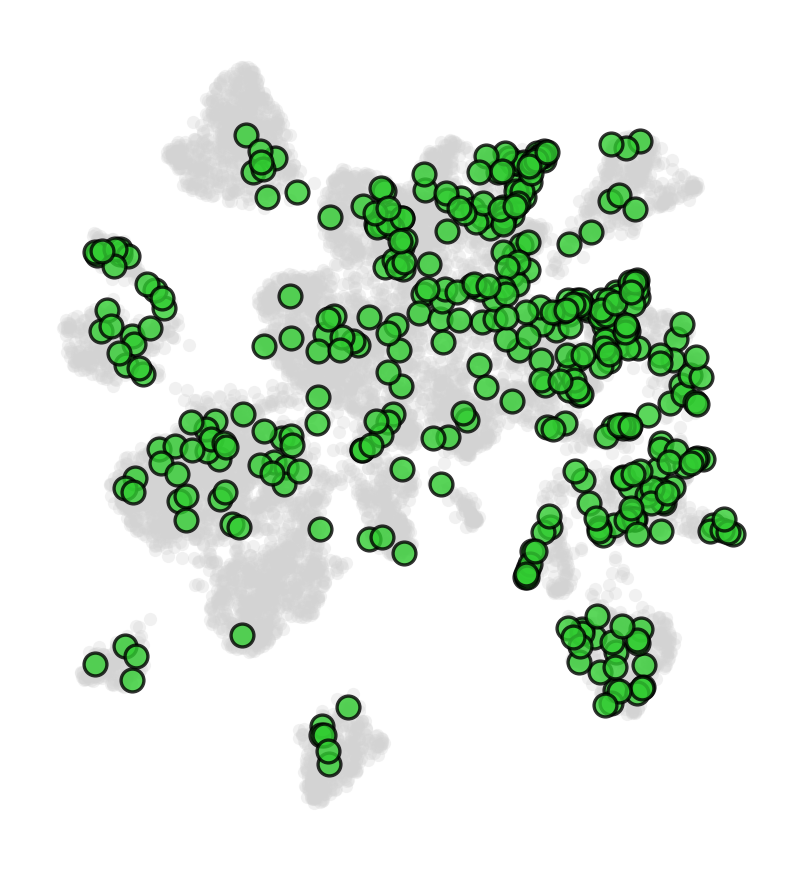

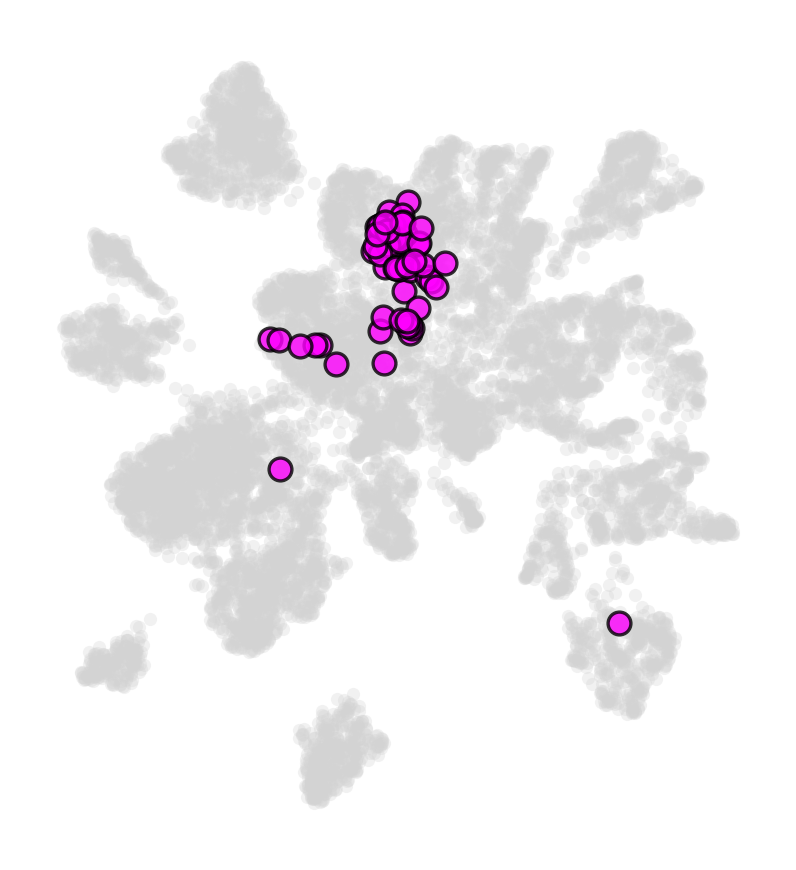

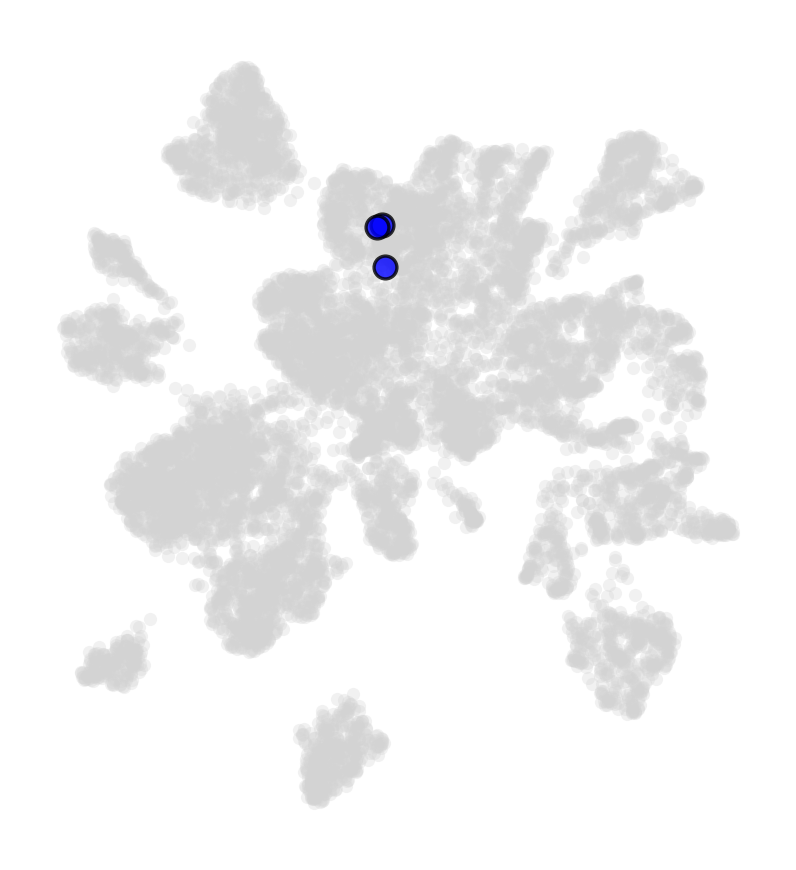

In [24]:
plot_umaps(
    adata,
    label_cols=labels,
    true_color_map=true_color_map,
    false_color="lightgray",
    true_size=30,
    false_size=10,
    edgecolor="black",
    linewidth=0.8,
    alpha_false=0.3,
    alpha_true=0.8,
    save_path = plot_out_dir
)

## Check reporter status and bar plots

In [28]:
group_col = 'neuron_label'
labels = ["EGFP_Seq1_hi", "dTomato_Seq2_hi", "EGFP_dTomato_dual_hi"]
for dual_col in labels:
    # output 
    df = adata.obs[[group_col, dual_col]].copy()
    df[dual_col] = df[dual_col].astype(bool)
    df[group_col] = df[group_col].astype(str).replace("nan", "Unknown")
    
    # Count dual positives per group (correct)
    dual_counts = df.groupby(group_col)[dual_col].sum()
    
    total_dual = dual_counts.sum()
    print('number +: ', total_dual)
    
    # percentage
    stats = (dual_counts / total_dual * 100).sort_values(ascending=False)
    
    count_percent_df = pd.concat([dual_counts, stats], axis=1)
    count_percent_df.columns = ['count', 'percent']
    count_percent_df = count_percent_df.sort_values(by='percent', ascending=False)
    print(count_percent_df)

number +:  398
                            count    percent
neuron_label                                
CGRP-Eta                       67  16.834171
Abeta-RA-LTMR                  52  13.065327
CGRP-Zeta                      48  12.060302
Abeta-Field                    46  11.557789
Nonpeptidergic nociceptors     36   9.045226
Proprioceptors                 33   8.291457
CGRP-Gamma 1                   25   6.281407
CGRP-Gamma 2                   25   6.281407
CGRP-Theta                     24   6.030151
C-LTMR                          8   2.010050
CGRP-Alpha                      8   2.010050
Adelta-LTMR                     7   1.758794
TrpM8                           7   1.758794
CGRP-Epsilion                   6   1.507538
Sst                             6   1.507538
CGRP-Beta                       0   0.000000
number +:  64
                            count  percent
neuron_label                              
CGRP-Gamma 2                   42  65.6250
CGRP-Gamma 1                   1

In [29]:
# Show single+ all together
counts_series = adata.obs.value_counts(['EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi'])
counts_df = counts_series.reset_index(name='cell_count')
counts_df

,EGFP_Seq1_hi,dTomato_Seq2_hi,EGFP_dTomato_dual_hi,cell_count
0,False,False,False,9817
1,True,False,False,395
2,False,True,False,61
3,True,True,True,3


In [30]:
adata.obs['reporter_status'].unique().tolist()

['none', 'EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi']

In [31]:
counts = adata.obs.value_counts(['reporter_status'])
counts

reporter_status     
none                    9817
EGFP_Seq1_hi             395
dTomato_Seq2_hi           61
EGFP_dTomato_dual_hi       3
Name: count, dtype: int64

In [32]:
counts = adata.obs.value_counts(['EGFP_Seq1_hi'])
counts

EGFP_Seq1_hi
False           9878
True             398
Name: count, dtype: int64

In [33]:
counts = adata.obs.value_counts(['dTomato_Seq2_hi'])
counts

dTomato_Seq2_hi
False              10212
True                  64
Name: count, dtype: int64

In [34]:
counts = adata.obs.value_counts(['EGFP_dTomato_dual_hi'])
counts

EGFP_dTomato_dual_hi
False                   10273
True                        3
Name: count, dtype: int64

### Export reporter status counts as csv
We will make four versions of these csvs
1. Counts of reporter positive cells where the EGFP+ and dTomato+ counts are not single positive (e.g. they include that dual+ cells)
2. Counts of reporter positive cells where the EGFP+ and dTomato+ counts are single positive
3. For each of these 2 options, generate the table first with counts separated by cell type and then collapsed to combine all cell types

### Csvs for single positives
Use, 'reporter status' column, which already contains single+ and dual+

In [35]:
# counts by neuron label
combined_counts = adata.obs.value_counts(['neuron_label', 'reporter_status'])

combined_df = combined_counts.reset_index(name='cell_count')

# # 3. Apply your rename_map to the reporter_status column
# combined_df['reporter_status'] = combined_df['reporter_status'].map(rename_map)

# Sort for better readability (Group by neuron, then descending count)
combined_df = combined_df.sort_values(['neuron_label', 'cell_count'], ascending=[True, False])

# now collapse cell types
combined_df_collapse = combined_df.groupby('reporter_status')['cell_count'].sum().reset_index().sort_values(by='cell_count', ascending=False)

# Export
combined_df.to_csv(os.path.join(output_dir, 'neuron_label_reporter_status_single_positive.csv'), index=False)
combined_df_collapse.to_csv(os.path.join(output_dir, 'all_neurons_reporter_status_single_positive.csv'), index=False)

/tmp/ipykernel_9364/4004220602.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combined_df_collapse = combined_df.groupby('reporter_status')['cell_count'].sum().reset_index().sort_values(by='cell_count', ascending=False)


In [36]:
combined_df.head()

,neuron_label,reporter_status,cell_count
6,Abeta-Field,none,512
19,Abeta-Field,EGFP_Seq1_hi,46
7,Abeta-RA-LTMR,none,499
17,Abeta-RA-LTMR,EGFP_Seq1_hi,52
11,Adelta-LTMR,none,371


In [37]:
combined_df_collapse

,reporter_status,cell_count
3,none,9817
0,EGFP_Seq1_hi,395
2,dTomato_Seq2_hi,61
1,EGFP_dTomato_dual_hi,3


### Csvs for all reporter positives (not requiring single positive)

Use the individual reporter True/False columns for counting

In [38]:
# counts by neuron label
single_reporter_cols = ['EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi']
combined_counts = adata.obs.groupby('neuron_label')[single_reporter_cols].sum()
is_negative = adata.obs[single_reporter_cols].sum(axis=1) == 0
combined_counts['Negative'] = adata.obs[is_negative].groupby('neuron_label').size()


# Reshape from "Wide" to "Long" format 
combined_df = combined_counts.stack().reset_index()

# relabel columns
combined_df.columns = ['neuron_label', 'reporter_status', 'cell_count']

# sort
combined_df = combined_df.sort_values(['neuron_label', 'cell_count'], ascending=[True, False])

# now collapse cell types
combined_df_collapse = combined_df.groupby('reporter_status')['cell_count'].sum().reset_index().sort_values(by='cell_count', ascending=False)

# Export
combined_df.to_csv(os.path.join(output_dir, 'neuron_label_reporter_status_not_single_positive.csv'), index=False)
combined_df_collapse.to_csv(os.path.join(output_dir, 'all_neurons_reporter_status_not_single_positive.csv'), index=False)

/tmp/ipykernel_9364/3776613712.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combined_counts = adata.obs.groupby('neuron_label')[single_reporter_cols].sum()
/tmp/ipykernel_9364/3776613712.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combined_counts['Negative'] = adata.obs[is_negative].groupby('neuron_label').size()


In [39]:
combined_df

,neuron_label,reporter_status,cell_count
3,Abeta-Field,Negative,512
0,Abeta-Field,EGFP_Seq1_hi,46
1,Abeta-Field,dTomato_Seq2_hi,0
2,Abeta-Field,EGFP_dTomato_dual_hi,0
7,Abeta-RA-LTMR,Negative,499
...,...,...,...
58,Sst,EGFP_dTomato_dual_hi,0
63,TrpM8,Negative,396
60,TrpM8,EGFP_Seq1_hi,7
61,TrpM8,dTomato_Seq2_hi,0


In [40]:
combined_df_collapse

,reporter_status,cell_count
2,Negative,9817
0,EGFP_Seq1_hi,398
3,dTomato_Seq2_hi,64
1,EGFP_dTomato_dual_hi,3


### Plot reporter status barplots

### Counts - showing reporter+ (not necessarily single positive)

number +:  3
number +:  398
number +:  64


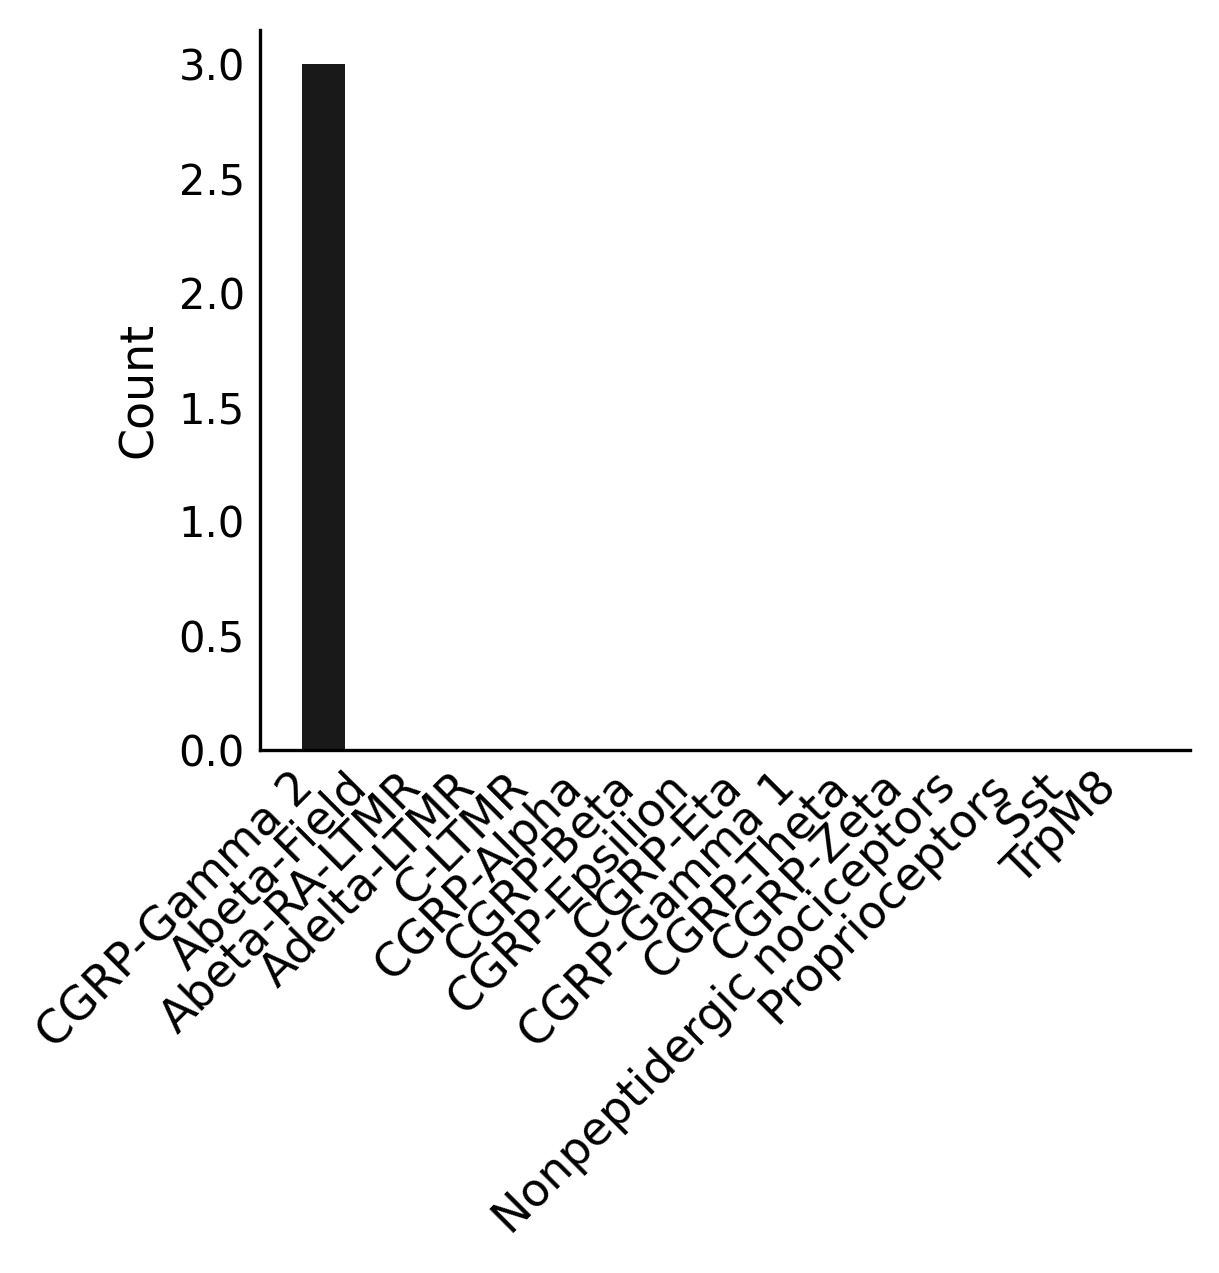

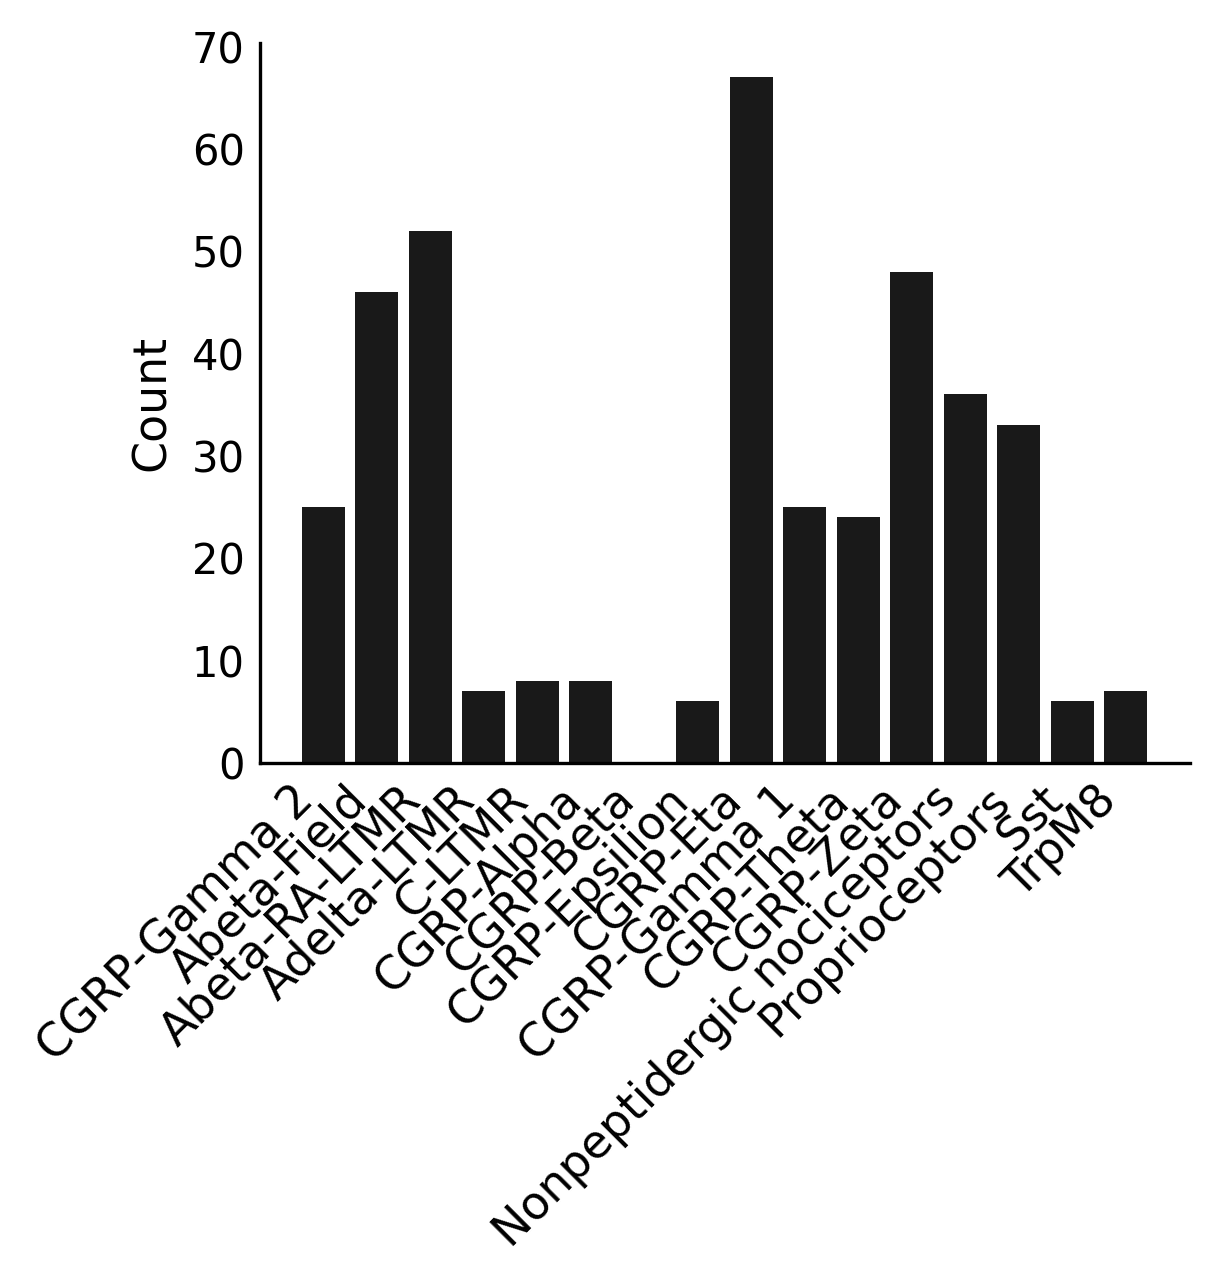

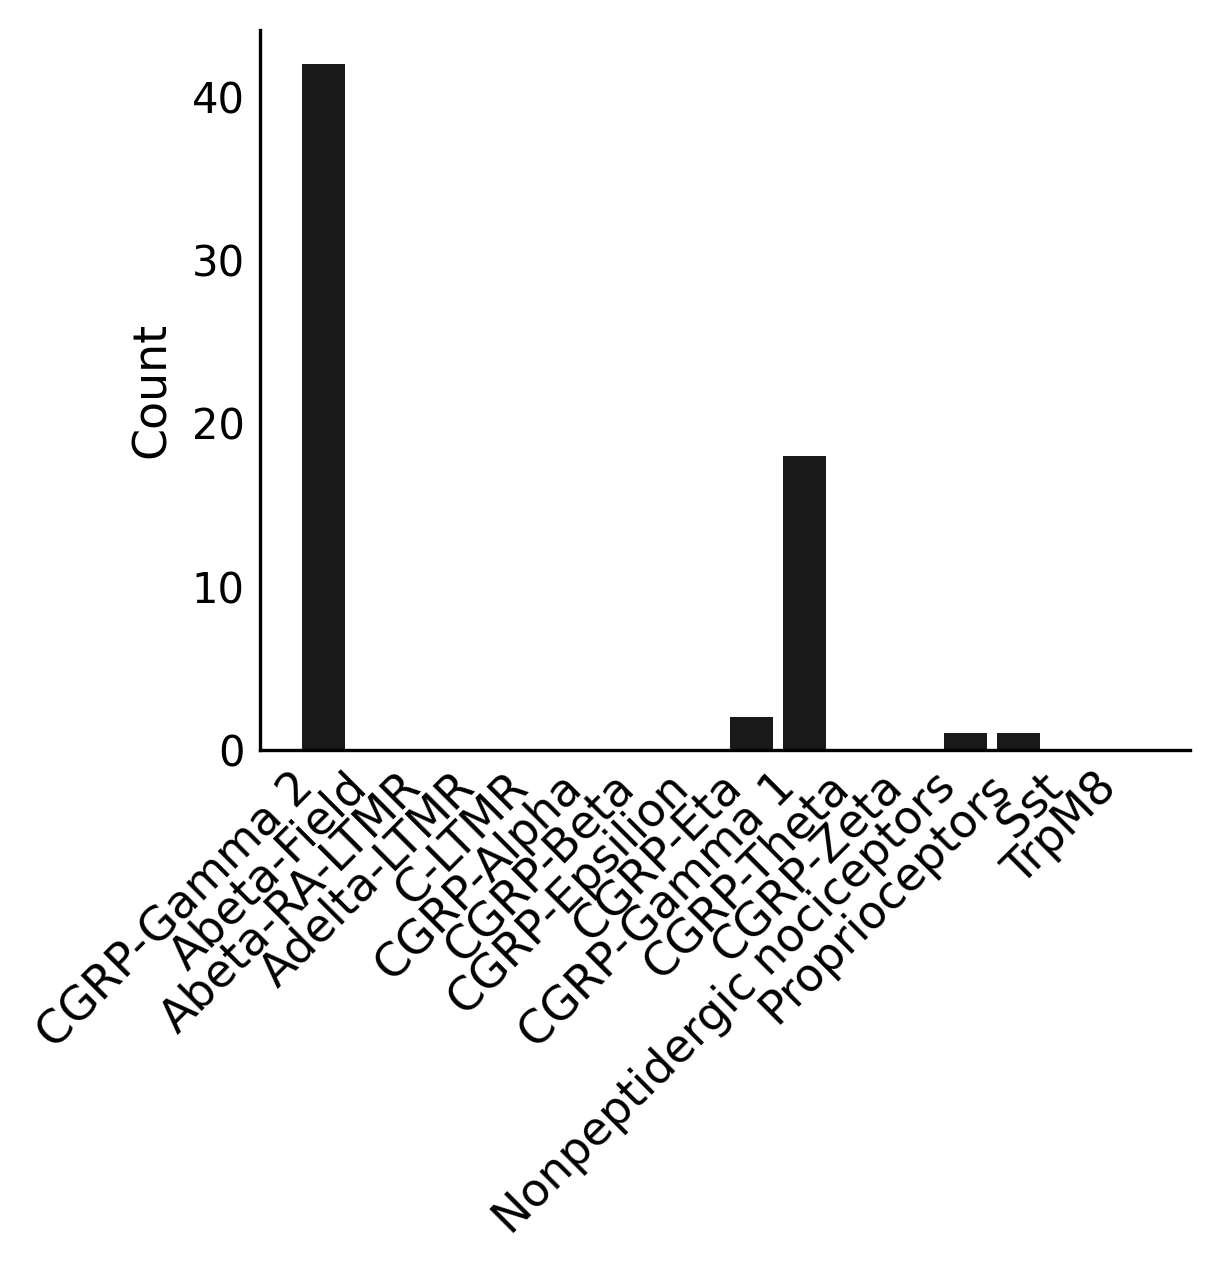

In [41]:
# set cell type order based on dual positive order
_, dual_order = barplot_dual_distribution(adata, population_name = 'Double+',
                                          dual_col="EGFP_dTomato_dual_hi",
                          return_group_order=True,
                            group_order=None)   
plt.savefig(os.path.join(plot_out_dir, "dual_distribution_count.pdf"), format='pdf', bbox_inches='tight')

barplot_dual_distribution(adata,population_name = 'EGFP+',
                          dual_col="EGFP_Seq1_hi",
                         group_order = dual_order)
plt.savefig(os.path.join(plot_out_dir, "EGFP_distribution_count.pdf"), format='pdf', bbox_inches='tight')

barplot_dual_distribution(adata,population_name = 'dTomato+',
                          dual_col="dTomato_Seq2_hi",
                         group_order = dual_order)
plt.savefig(os.path.join(plot_out_dir, "dTomato_distribution_count.pdf"), format='pdf', bbox_inches='tight')



### Counts - showing single positive only for each single reporter

number +:  395
number +:  61


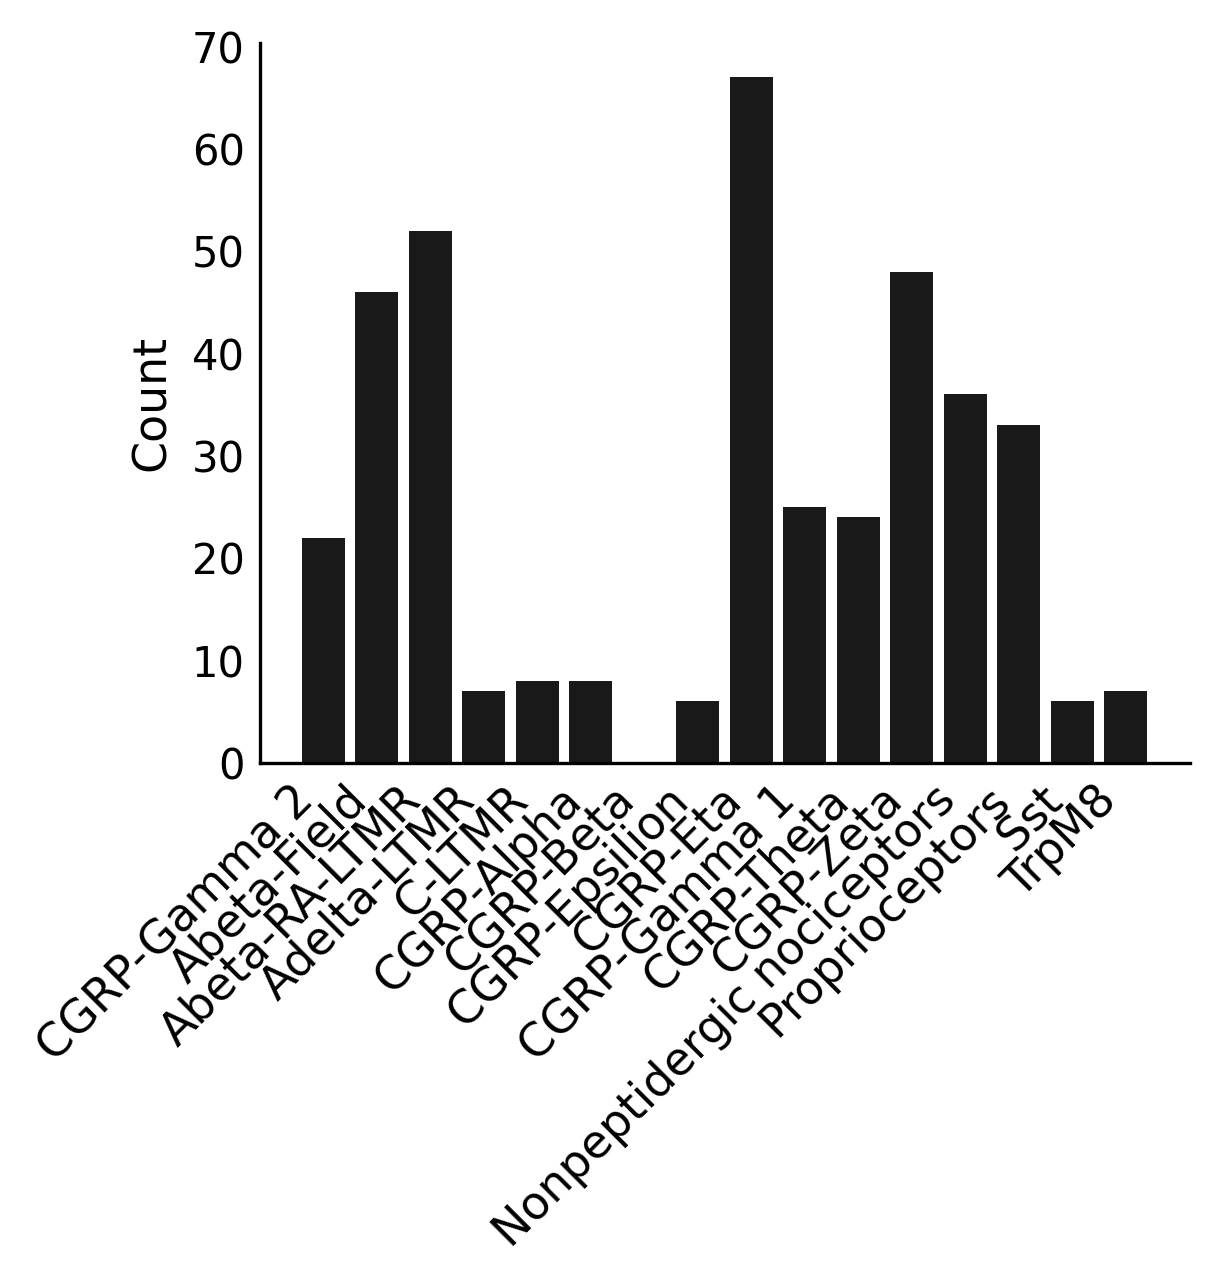

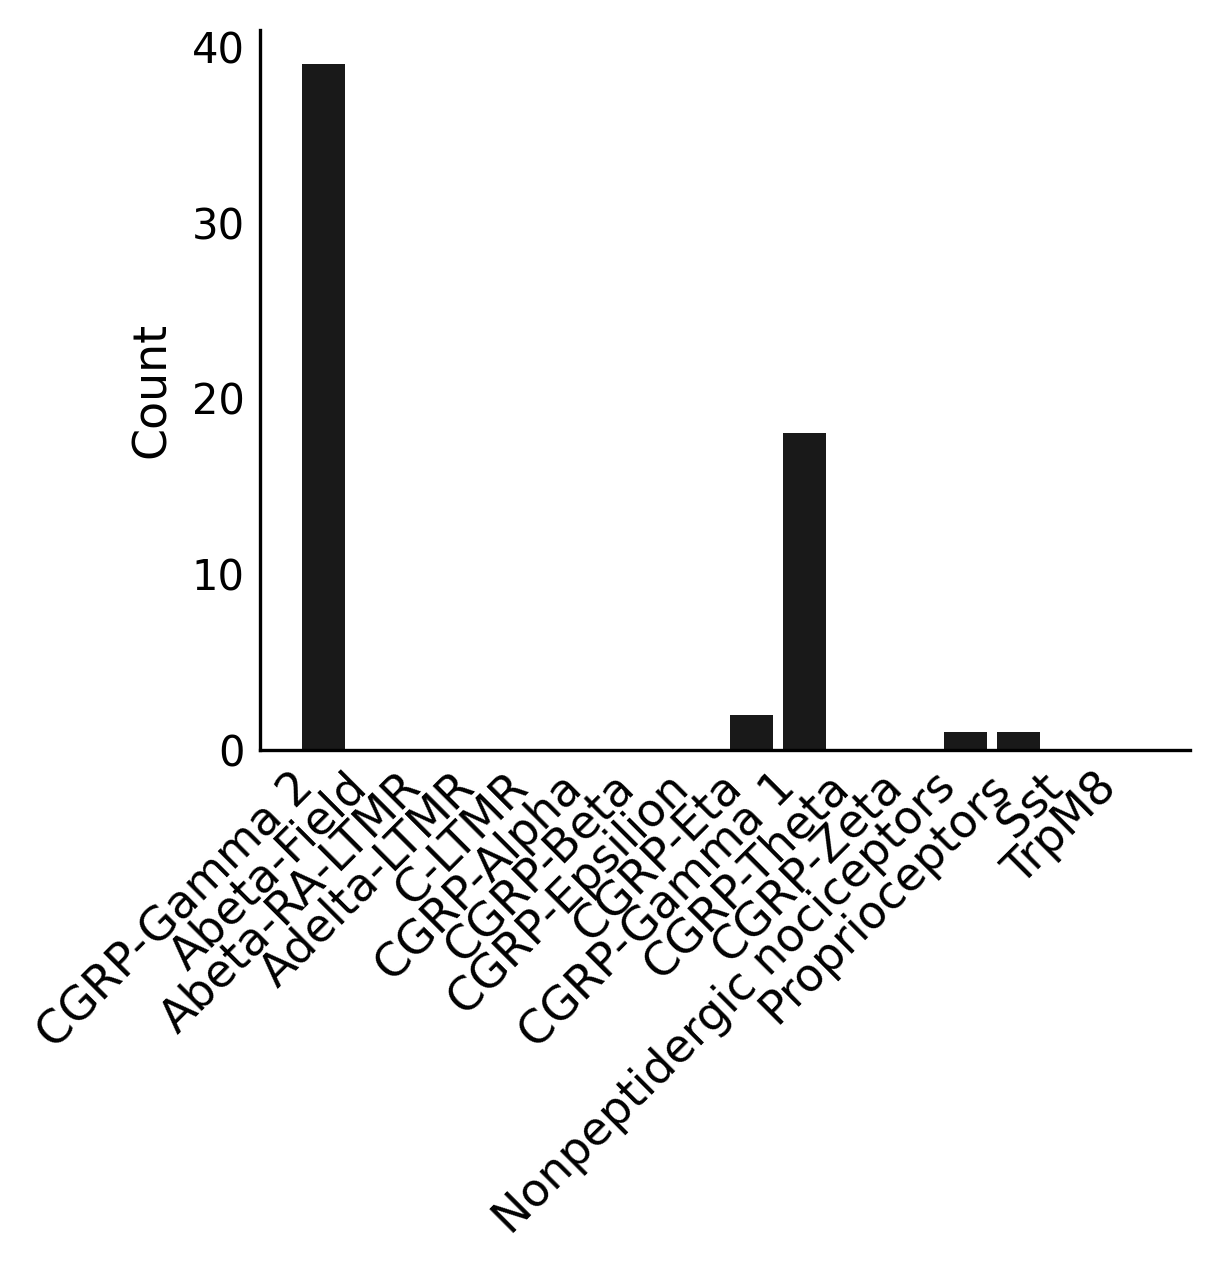

In [42]:
# set cell type order based on dual positive order

# make new temporary column 
tmp = adata.copy()
tmp.obs['EGFP_single_positive'] = False
tmp.obs['dTomato_single_positive'] = False
tmp.obs.loc[tmp.obs['reporter_status']=='EGFP_Seq1_hi', 'EGFP_single_positive'] = True
tmp.obs.loc[tmp.obs['reporter_status']=='dTomato_Seq2_hi', 'dTomato_single_positive'] = True

barplot_dual_distribution(tmp,population_name = 'EGFP+',
                          dual_col="EGFP_single_positive",
                         group_order = dual_order)
plt.savefig(os.path.join(plot_out_dir, "EGFP_distribution_count_single_positive.pdf"), format='pdf', bbox_inches='tight')

barplot_dual_distribution(tmp,population_name = 'dTomato+',
                          dual_col="dTomato_single_positive",
                         group_order = dual_order)
plt.savefig(os.path.join(plot_out_dir, "dTomato_distribution_count_single_positive.pdf"), format='pdf', bbox_inches='tight')



### Percent - showing reporter+ (not single positive)

number +:  3
number +:  398
number +:  64


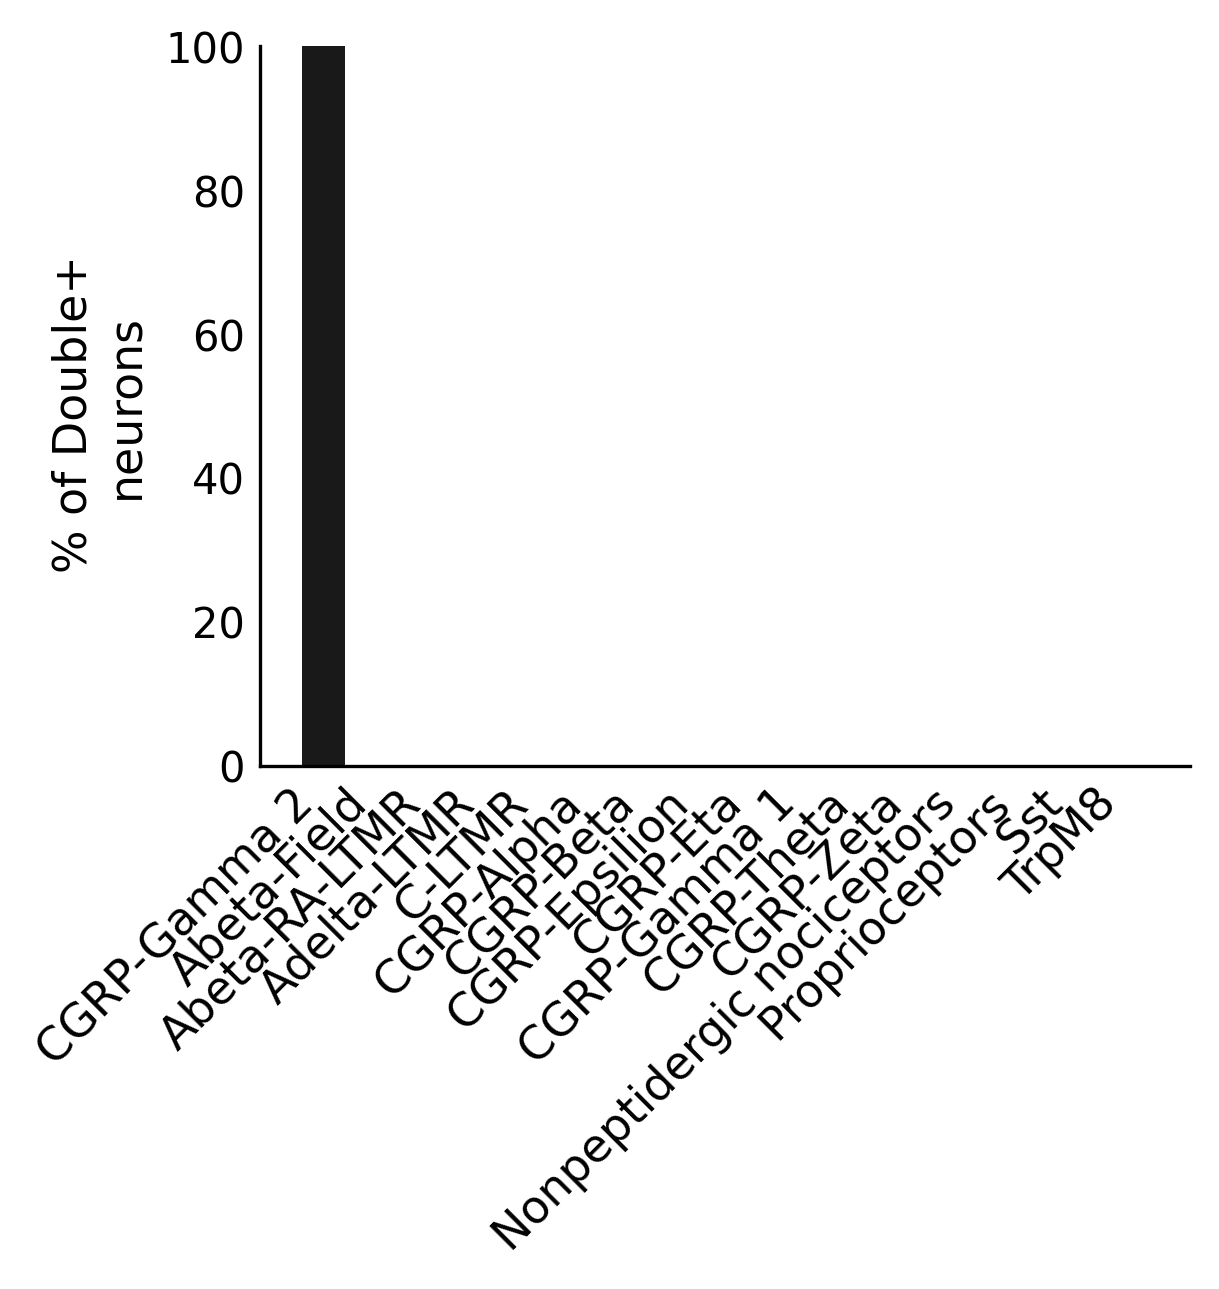

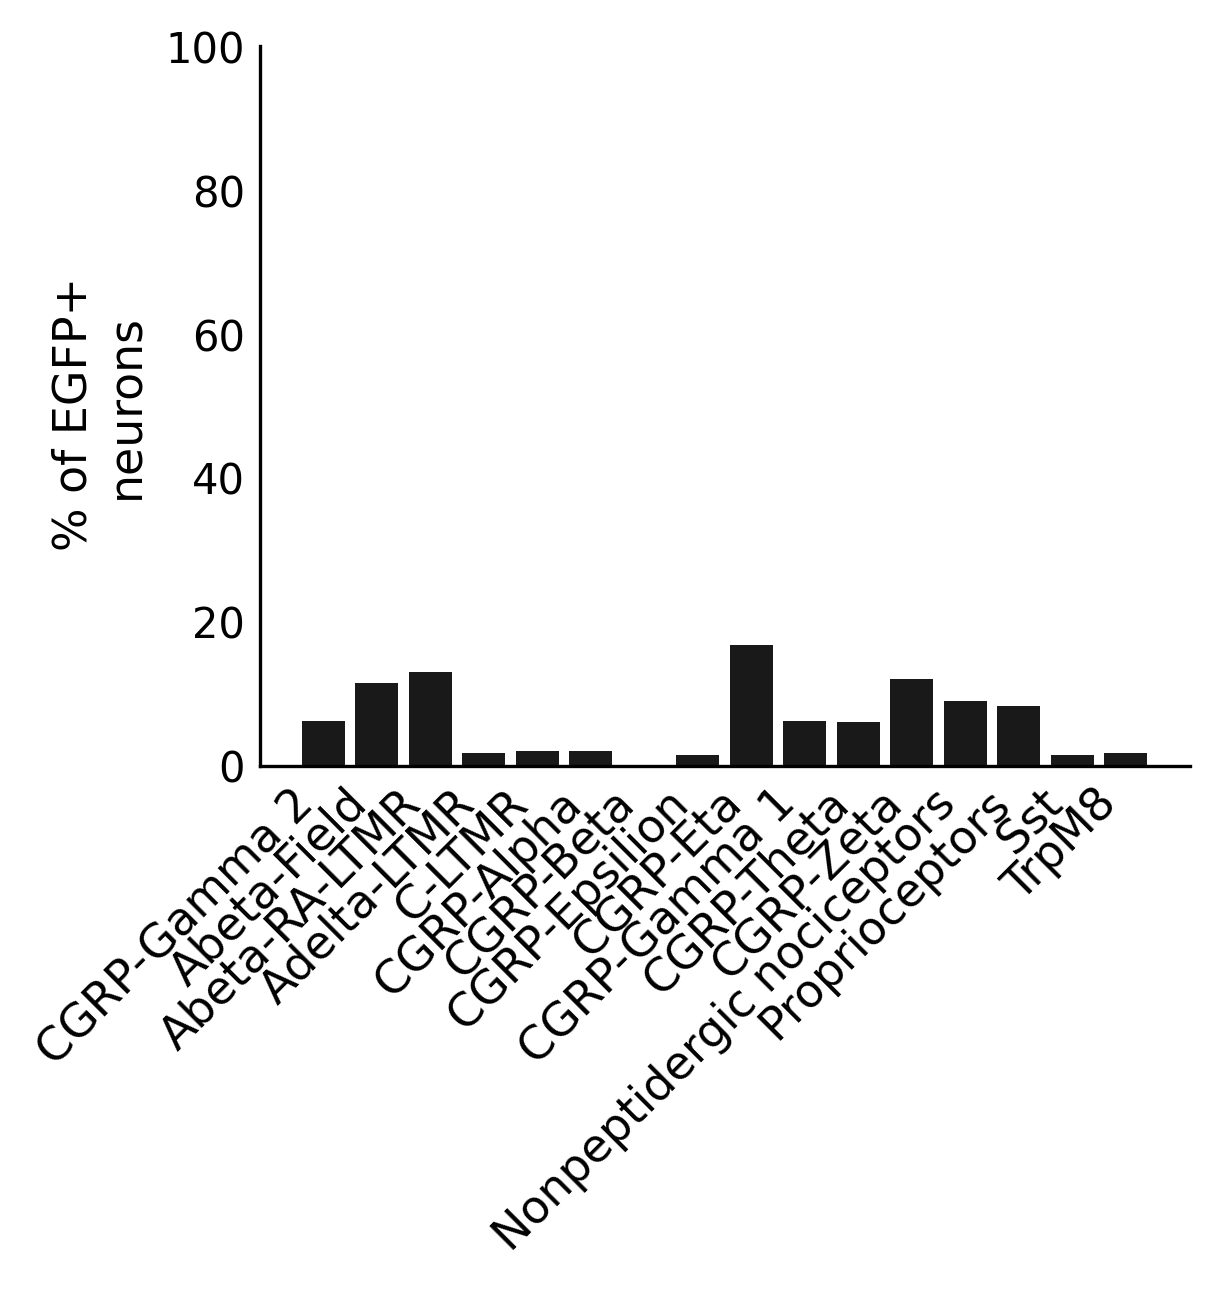

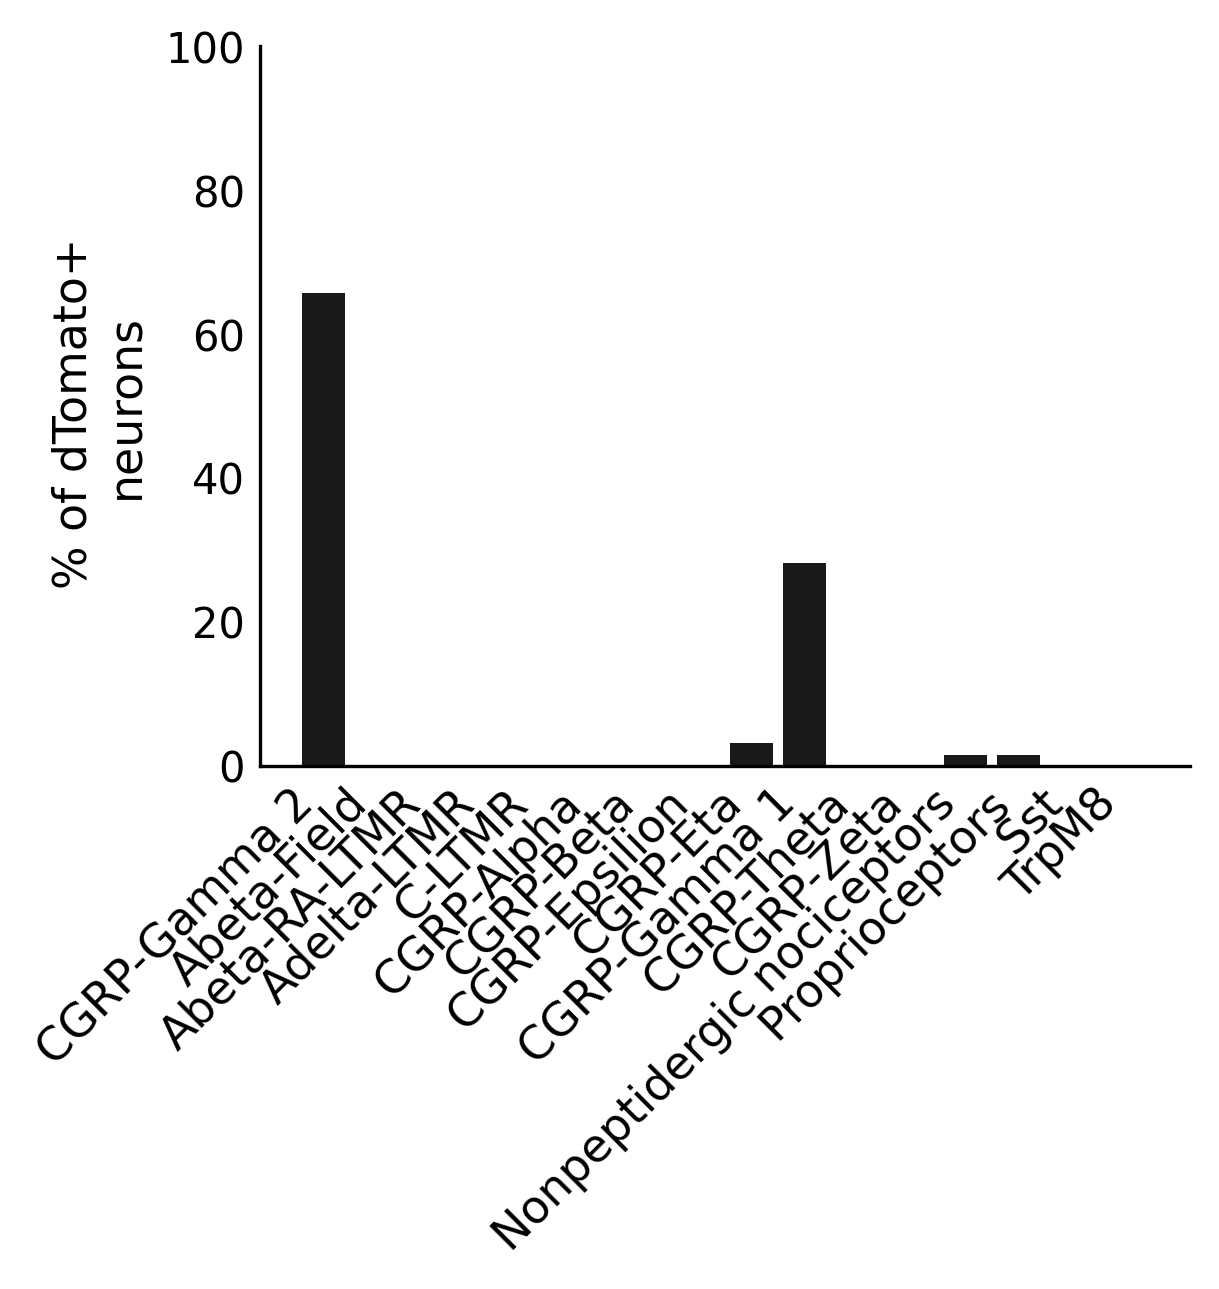

In [43]:
# use cell label ordering from dual+ counts plot above
barplot_dual_distribution(adata, population_name = 'Double+',
                          dual_col="EGFP_dTomato_dual_hi", plot_counts = False,
                         group_order = dual_order)
plt.savefig(os.path.join(plot_out_dir, "dual_distribution_percent.pdf"), format='pdf', bbox_inches='tight')

barplot_dual_distribution(adata, population_name = 'EGFP+', 
                          dual_col="EGFP_Seq1_hi", plot_counts = False,
                         group_order = dual_order)
plt.savefig(os.path.join(plot_out_dir, "EGFP_distribution_percent.pdf"), format='pdf', bbox_inches='tight')

barplot_dual_distribution(adata, population_name = 'dTomato+', 
                          dual_col="dTomato_Seq2_hi", plot_counts = False,
                         group_order = dual_order)
plt.savefig(os.path.join(plot_out_dir, "dTomato_distribution_percent.pdf"), format='pdf', bbox_inches='tight')

### Percent - showing single positive only

number +:  395
number +:  61


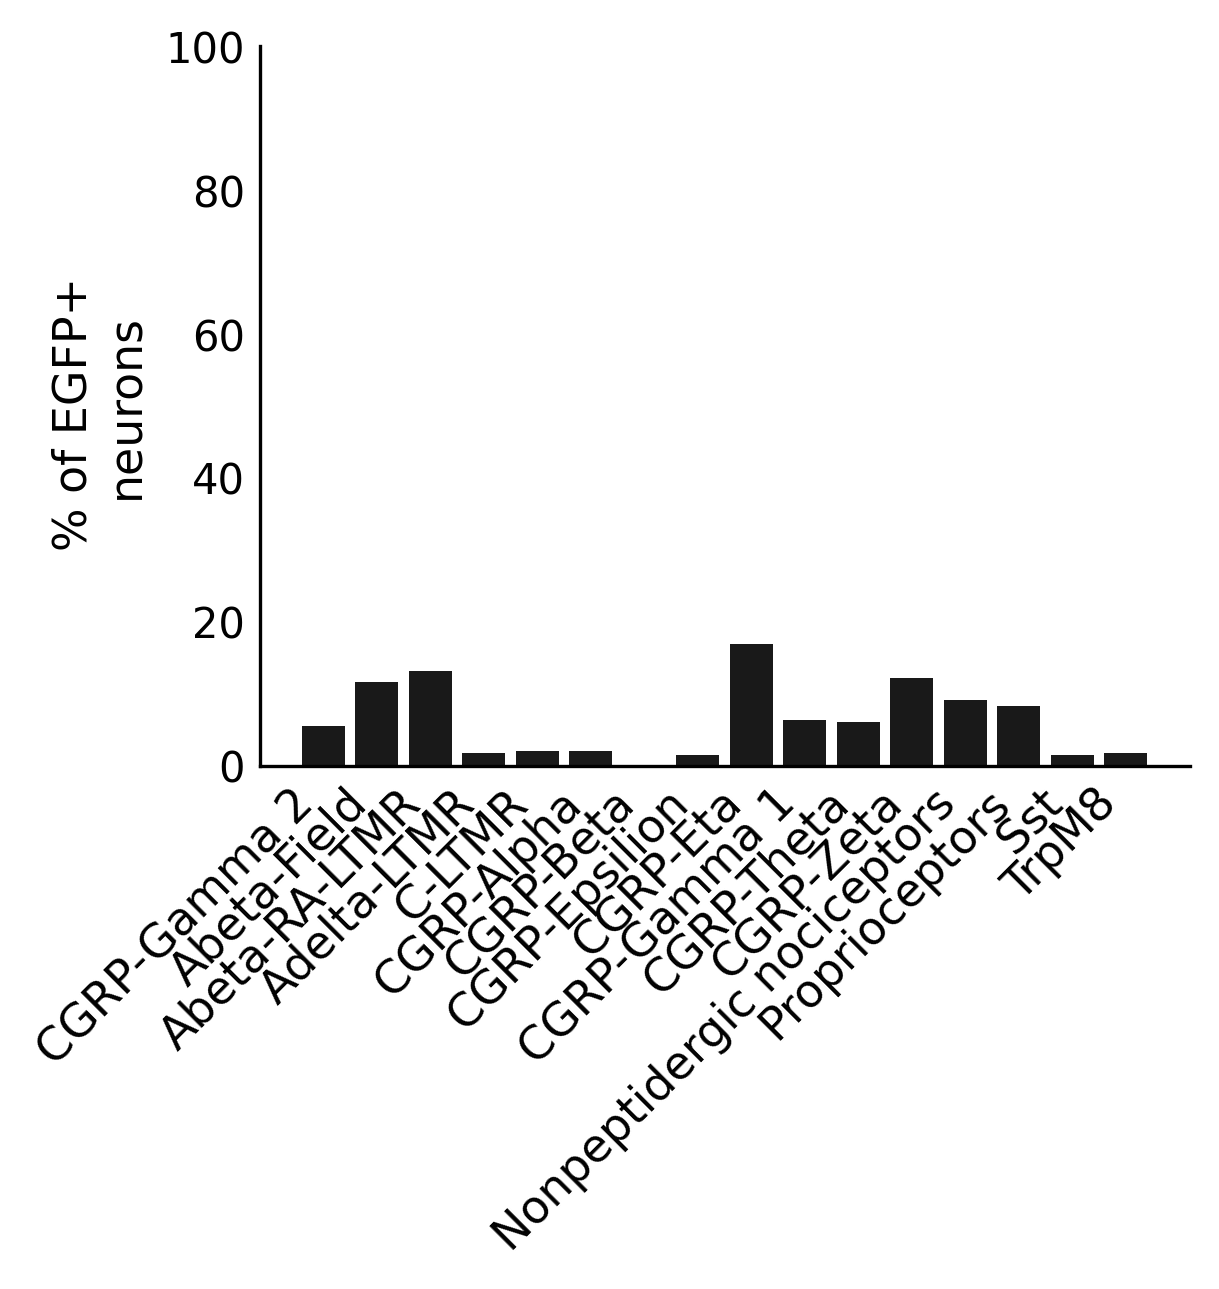

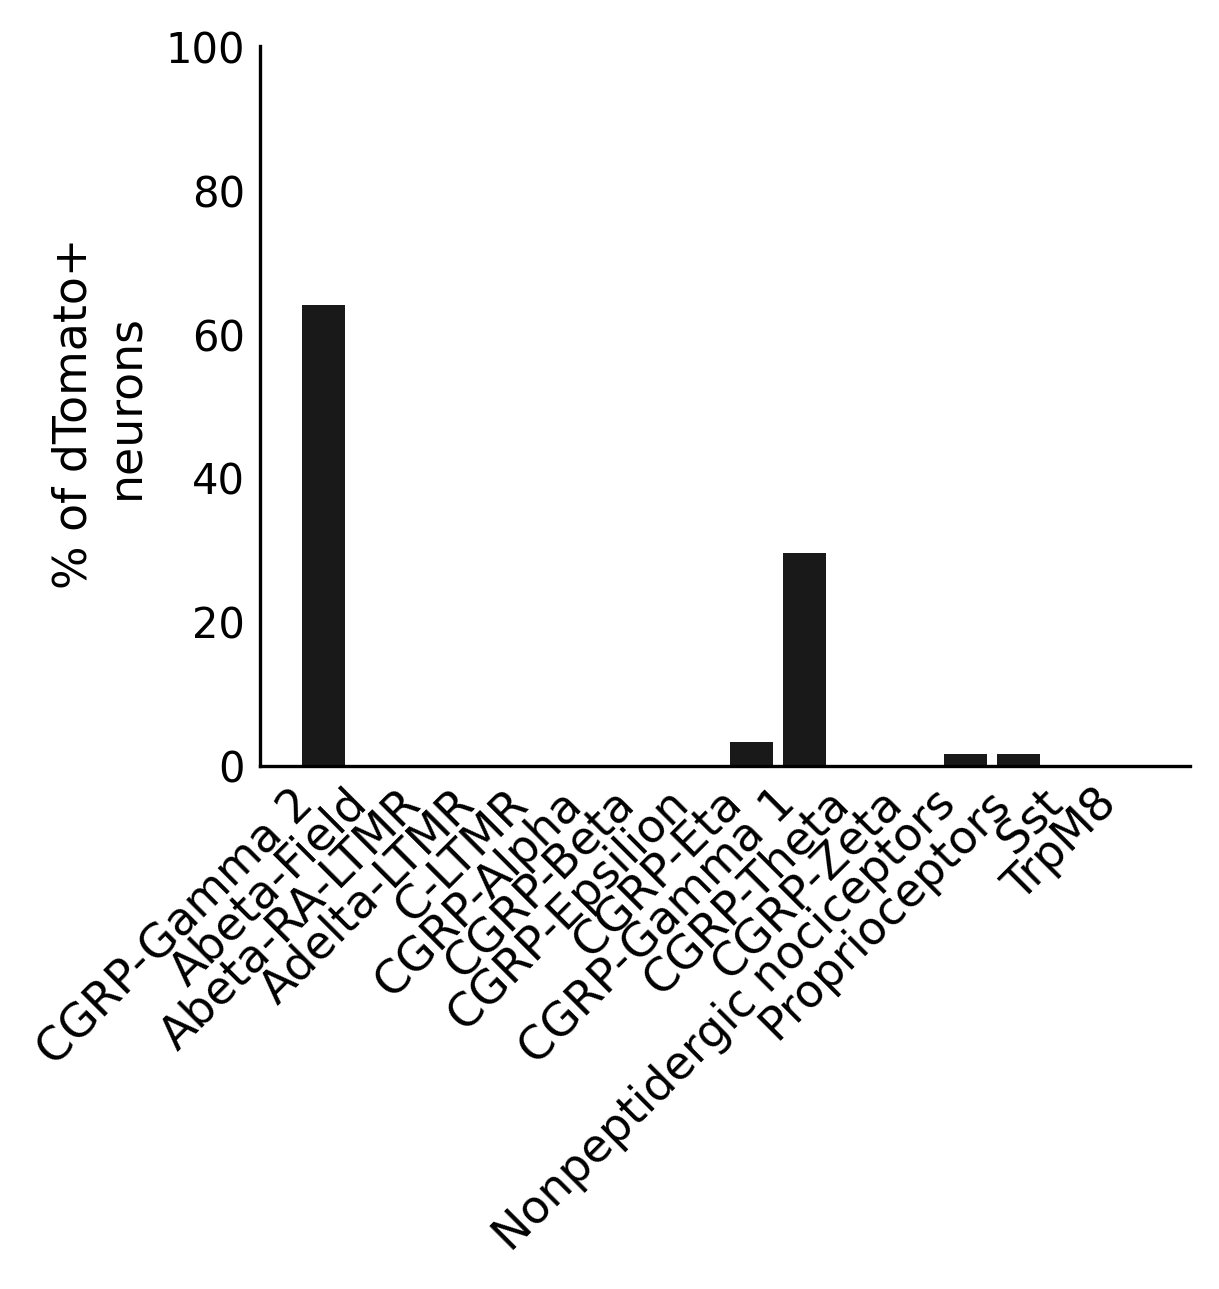

In [44]:
# set cell type order based on dual positive order

# make new temporary column 
tmp = adata.copy()
tmp.obs['EGFP_single_positive'] = False
tmp.obs['dTomato_single_positive'] = False
tmp.obs.loc[tmp.obs['reporter_status']=='EGFP_Seq1_hi', 'EGFP_single_positive'] = True
tmp.obs.loc[tmp.obs['reporter_status']=='dTomato_Seq2_hi', 'dTomato_single_positive'] = True

barplot_dual_distribution(tmp,population_name = 'EGFP+',
                          dual_col="EGFP_single_positive", plot_counts = False,
                         group_order = dual_order)
plt.savefig(os.path.join(plot_out_dir, "EGFP_distribution_percent_single_positive.pdf"), format='pdf', bbox_inches='tight')

barplot_dual_distribution(tmp,population_name = 'dTomato+',
                          dual_col="dTomato_single_positive",plot_counts = False,
                         group_order = dual_order)
plt.savefig(os.path.join(plot_out_dir, "dTomato_distribution_percent_single_positive.pdf"), format='pdf', bbox_inches='tight')



## Save label and reporter outputs for xenium explorer

In this adata object, the cell barcodes do not seen to have a suffix indicating the sample number. However, it looks like all indices are still unique. 

In [ ]:
adata.obs.index.is_unique

In [ ]:
adata.obs.head()

In [ ]:
adata.obs['sample_id'].unique().tolist()

In [ ]:
label_cols = ["cell_id","sample_id","neuron_label","EGFP_Seq1_hi", "dTomato_Seq2_hi", "EGFP_dTomato_dual_hi", "reporter_status"]
label_df = adata.obs[label_cols]

In [ ]:
# which samples contain dual+?
counts = label_df.value_counts(['sample_id', 'EGFP_dTomato_dual_hi'])
counts

In [ ]:
label_df.head()

In [ ]:
label_df['neuron_label'].unique().tolist()

### Output csvs with neuron label

In [ ]:
# for Xenium explorer, can only have one group
label_df_neuron_label = label_df.copy()
label_df_neuron_label['group'] = label_df_neuron_label['neuron_label']

# split to individual samples
for sample in adata.obs['sample_id'].unique().tolist():
    label_df_sample = label_df_neuron_label[label_df_neuron_label['sample_id']==sample]
    # save to csv 
    label_df_sample.to_csv(os.path.join(output_dir, f"label_df_{sample}_neuron_label.csv"),index=False)

### Output csvs with reporter status

In [ ]:
# for Xenium explorer, can only have one group
label_df_reporter = label_df.copy()
label_df_reporter['group'] = label_df_reporter['reporter_status']

# split to individual samples
for sample in adata.obs['sample_id'].unique().tolist():
    label_df_sample = label_df_reporter[label_df_reporter['sample_id']==sample]
    # save to csv 
    label_df_sample.to_csv(os.path.join(output_dir, f"label_df_{sample}_reporter.csv"),index=False)

## Subcluster CGRP gamma 

- Re-running MC subclustering code and saving updated visualizations
- Confirming I get the same plot results as MC

In [ ]:
# 1. Subset to the CGRP-Gamma population
gamma_adata = adata[adata.obs['seurat_labels'] == 'CGRP-Gamma'].copy()

# 2. Use scVI latent space instead of PCA for neighbors
sc.pp.neighbors(gamma_adata, use_rep='X_scVI_seurat_neuron')
sc.tl.umap(gamma_adata)
sc.tl.leiden(gamma_adata, resolution=0.1, key_added='gamma_subclusters')

# 3. Identify G1 vs G2 based on Chrna3 mean expression
# Temporarily pull gene expression into .obs to allow grouping
gamma_adata.obs['Chrna3_temp'] = gamma_adata[:, 'Chrna3'].X.toarray().flatten()

cluster_expr = gamma_adata.obs.groupby('gamma_subclusters', observed=False)['Chrna3_temp'].mean()
g2_cluster = cluster_expr.idxmax()
g1_cluster = cluster_expr.idxmin()

In [ ]:
# Clean up the temporary column to avoid plotting conflicts
del gamma_adata.obs['Chrna3_temp']

# 4. Create the final labels
label_map = {g1_cluster: 'CGRP-Gamma 1', g2_cluster: 'CGRP-Gamma 2'}
gamma_adata.obs['neuron_label_confirm'] = gamma_adata.obs['gamma_subclusters'].map(label_map)

# 5. Visualize to confirm the split
sc.pl.umap(gamma_adata, color=['neuron_label_confirm', 'neuron_label', 'Chrna3', 'Adra2a', 'reporter_status'])

### Save CGRP visualizations

In [ ]:
sc.pl.umap(gamma_adata, color='seurat_labels', frameon = False, title = '', show = False)
plt.savefig(os.path.join(plot_out_dir, f"CGRP_umap_all.pdf"), format='pdf', bbox_inches='tight')

sc.pl.umap(gamma_adata, color='neuron_label', frameon = False, title = '', show = False)
plt.savefig(os.path.join(plot_out_dir, f"CGRP_neuron_label.pdf"), format='pdf', bbox_inches='tight')

sc.pl.umap(gamma_adata, color='neuron_label', frameon = False, title = '', palette = ['#1f77b4', '#ff7f0e'], show = False)
plt.savefig(os.path.join(plot_out_dir, f"CGRP_neuron_label_blue_orange.pdf"), format='pdf', bbox_inches='tight')



In [ ]:
sc.pl.embedding(gamma_adata, basis = 'X_umap', color='Chrna3', cmap = 'viridis', frameon = False, show = False)
plt.savefig(os.path.join(plot_out_dir, f"CGRP_Chrna3.pdf"), format='pdf', bbox_inches='tight')

sc.pl.embedding(gamma_adata, basis = 'X_umap', color='Htr3a', cmap = 'viridis', frameon = False, show = False)
plt.savefig(os.path.join(plot_out_dir, f"CGRP_Htr3a.pdf"), format='pdf', bbox_inches='tight')

sc.pl.embedding(gamma_adata, basis = 'X_umap', color='Adra2a', cmap = 'viridis', frameon = False, show = False)
plt.savefig(os.path.join(plot_out_dir, f"CGRP_Adra2a.pdf"), format='pdf', bbox_inches='tight')

sc.pl.embedding(gamma_adata, basis = 'X_umap', color='Nos1', cmap = 'viridis', frameon = False, show = False)
plt.savefig(os.path.join(plot_out_dir, f"CGRP_Nos1.pdf"), format='pdf', bbox_inches='tight')

sc.pl.embedding(gamma_adata, basis = 'X_umap', color=['Chrna3','Htr3a','Adra2a','Nos1'], cmap = 'viridis', ncols = 2, frameon = False, show = False)
plt.savefig(os.path.join(plot_out_dir, f"CGRP_all4genes.pdf"), format='pdf', bbox_inches='tight')

### Proportions bar plot, extended data f

In [ ]:
def plot_dual_fraction_among_dtom(
    adata,
    dtom_col="dTomato_Seq2_hi",
    dual_col="EGFP_dTomato_dual_hi",
    mode="counts",  # Options: "counts" or "percent"
    colors=None,
    figsize=(3, 3)
):
    import seaborn as sns
    import matplotlib.pyplot as plt

    # 1. Logic for colors and masks (same as before)
    if colors is None:
        colors = {"Single": "crimson", "Dual": "gold"}

    dtom_mask = adata.obs[dtom_col].astype(bool)
    dual_mask = adata.obs[dual_col].astype(bool)

    n_dtom_total = dtom_mask.sum()
    n_dual = (dtom_mask & dual_mask).sum()
    n_dtom_only = n_dtom_total - n_dual

    # 2. Switch between Counts and Percent
    if mode == "percent":
        values = [(n_dtom_only / n_dtom_total * 100), (n_dual / n_dtom_total * 100)]
        ylabel = "Percent of dTom+ cells"
        fmt = ".1f" # Format for labels
        suffix = "%"
    else:
        values = [n_dtom_only, n_dual]
        ylabel = "Number of cells"
        fmt = "d" # Format for labels (integer)
        suffix = ""

    categories = ["dTom-only", "Dual+"]
    plot_colors = [colors["Single"], colors["Dual"]]

    # 3. Plotting
    plt.figure(figsize=figsize)
    bars = plt.bar(categories, values, color=plot_colors, edgecolor="black")

    # 4. Add dynamic labels on top of bars
    for bar, val in zip(bars, values):
        # We still show both raw and % in the text label for clarity
        raw_val = n_dtom_only if bar.get_x() < 0.5 else n_dual
        perc = (raw_val / n_dtom_total * 100)
        
        plt.text(
            bar.get_x() + bar.get_width()/2,
            val,
            f"{raw_val}\n({perc:.1f}%)",
            ha="center", va="bottom", fontsize=10
        )

    plt.ylabel(ylabel)
    
    sns.despine() # Remove top and right box
    plt.tight_layout()
    # plt.show()

    return {"fraction_dual": n_dual / n_dtom_total}

In [ ]:
stats = plot_dual_fraction_among_dtom(
    adata,
    colors={
        "Single": "magenta",
        "Dual": "blue"
    }
)
plt.savefig(os.path.join(plot_out_dir, f"dtomato_percent_dual_counts.pdf"), format='pdf', bbox_inches='tight')

In [ ]:
stats = plot_dual_fraction_among_dtom(
    adata,
    mode='percent',
    colors={
        "Single": "magenta",
        "Dual": "blue"
    }
)
plt.savefig(os.path.join(plot_out_dir, f"dtomato_percent_dual_percent.pdf"), format='pdf', bbox_inches='tight')

# Investigating Abeta GFP+ cells

## Where are they in the guassian thresholding map?

In [ ]:
adata.obs.columns

In [ ]:
adata.obs['neuron_label'].unique().tolist()

In [ ]:
test_classes = plot_gaussian(adata_480, 
                        genes = ["EGFP_Seq1", "dTomato_Seq2"],
                        # gene_thresholds = (0.9995, 0.99),
                        gene_thresholds = (0.99, 0.99),      
                        # gene_thresholds = (0.995, 0.99),
                        set_thresholds_on_dual_subsetted_data = True,
                        highlight_color = "green",
                        highlight_size = 10,
                        return_reporter_classes = True)

In [ ]:
# set up masks

# ab gfp+ cells
ab_gfp_mask = (adata.obs['EGFP_Seq1_hi']==True) & (adata.obs['neuron_label']=='Abeta-RA-LTMR')
print(sum(ab_gfp_mask))
ab_gfp_barcodes = adata.obs_names[ab_gfp_mask]

# all neurons
all_neurons_barcodes = adata.obs_names

In [ ]:
test_classes = plot_gaussian(adata_480, 
                        genes = ["EGFP_Seq1", "dTomato_Seq2"],
                        gene_thresholds = (0.9995, 0.99),
                        # gene_thresholds = (0.99, 0.99),      
                        # gene_thresholds = (0.995, 0.99),
                        set_thresholds_on_dual_subsetted_data = False,
                        highlight_barcodes = ab_gfp_barcodes.tolist(),
                        highlight_color = "green",
                        highlight_size = 10,
                        return_reporter_classes = True)

In [ ]:
test_classes_neurons = test_classes[test_classes.index.isin(all_neurons_barcodes)]

In [ ]:
sum(test_classes_neurons[test_classes_neurons.index.isin(ab_gfp_barcodes)]['EGFP_Seq1_hi'])

In [ ]:
sum(test_classes_neurons['EGFP_dTomato_dual_hi'])

## Test area filtering - does is remove AB single positive cells? 

No it does not


In [ ]:
group_col = 'neuron_label'
areas = adata.obs[['cell_area', group_col]].copy()
areas[group_col] = areas[group_col].astype(str).replace("nan", "Unknown")

# Loop through each unique neuron type
for label in areas[group_col].unique():
    subset = areas[areas[group_col] == label]
    
    plt.figure(figsize=(3, 2))
    plt.hist(subset['cell_area'], bins=100, color='skyblue', edgecolor='black')
    plt.axvline(100, linestyle = '--')
    plt.title(f"{label}")
    plt.xlabel("Area")
    plt.ylabel("Count")
    sns.despine()
    plt.show()

In [ ]:
min_area = 100
adata_area_filter = adata[adata.obs['cell_area']>min_area, :].copy()
print(adata.shape)
print(adata_area_filter.shape)

In [ ]:
group_col = 'neuron_label'
dual_col = 'EGFP_Seq1_hi'
# dual_col = 'EGFP_dTomato_dual_hi'
# output 
df = adata_area_filter.obs[[group_col, dual_col]].copy()
df[dual_col] = df[dual_col].astype(bool)
df[group_col] = df[group_col].astype(str).replace("nan", "Unknown")

# Count dual positives per group (correct)
dual_counts = df.groupby(group_col)[dual_col].sum()

total_dual = dual_counts.sum()
print('number +: ', total_dual)

# percentage
stats = (dual_counts / total_dual * 100).sort_values(ascending=False)

count_percent_df = pd.concat([dual_counts, stats], axis=1)
count_percent_df.columns = ['count', 'percent']
count_percent_df = count_percent_df.sort_values(by='percent', ascending=False)
count_percent_df